<center>

# Universidad nacional Autónoma de México
# 
# Facultad de Ingeniería
#
## Robótica
#
## Primer parcial
#
## Profesor: Erick Peña Medina

## Alumna: López González Pamela Citlali Atletl

## No. de cuenta:
## 316040518


# Índice

1.	Introducción
#
2.	Objetivo
#
3.	Modelo cinemático de la postura del robot
#
4.	Modelado cinemático de las velocidades
#
5.	Modelo cinemático de las aceleraciones 
# 
6.	Modelo dinámico 
#
7.	Código de Matlab
#
8.	Conclusiones
#
9.	Reeferncias


# 1. Introducción


# 2. Objetivo
La compresión y la aplicación de los cálculos de cinemática y dinámica directa e inversa, que se aprendieron en clase, en un robot tipo SCARA.



# 3. Modelo cinemático de la postura del robot
### Modelo de Cinemática Directo del Robot SCARA

Para determinar la postura del vector final en el espacio de la tarea, se establece primero una función de transformación homogénea general $T_{ij}$ que describe la relación espacial entre eslabones mediante parámetros de traslación $(x, y, z)$ y rotación $(\gamma, \beta, \alpha)$, difiniendose de la siguiente forma:

$$T_{ij}(x_{i,j},y_{i,j},z_{i,j},gi_{i,j},bi_{i,j},ai_{i,j}) = \begin{bmatrix} \cos(ai_j)\cos(bi_j) & \cos(ai_j)\sin(bi_j)\sin(gi_j)-\sin(ai_j)\cos(gi_j) & \sin(ai_j)\sin(gi_j)+\cos(ai_j)\sin(bi_j)\cos(gi_j) & x_{i,j} \\ \sin(ai_j)\cos(bi_j) & \cos(ai_j)\cos(gi_j)+\sin(ai_j)\sin(bi_j)\sin(gi_j) & \sin(ai_j)\sin(bi_j)\cos(gi_j)-\cos(ai_j)\sin(gi_j) & y_{i,j} \\ -\sin(bi_j) & \cos(bi_j)\sin(gi_j) & \cos(bi_j)\cos(gi_j) & z_{i,j} \\ 0 & 0 & 0 & 1 \end{bmatrix}$$


Para describir la configuración espacial del robot SCARA, se definen las matrices de transformación homogénea para cada articulación y eslabón. Basándose en los parámetros de diseño, las transformaciones locales se expresan como:

$$T_{0,1} = \begin{pmatrix} \cos(\theta_{0,1}) & -\sin(\theta_{0,1}) & 0 & x_{0,1} \\ \sin(\theta_{0,1}) & \cos(\theta_{0,1}) & 0 & y_{0,1} \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \end{pmatrix}$$

$$T_{1,2} = \begin{pmatrix} \cos(\theta_{1,2}) & -\sin(\theta_{1,2}) & 0 & L_{1} \\ \sin(\theta_{1,2}) & \cos(\theta_{1,2}) & 0 & 0 \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \end{pmatrix}$$

$$T_{2,3} = \begin{pmatrix} \cos(\theta_{2,3}) & -\sin(\theta_{2,3}) & 0 & L_{2} \\ \sin(\theta_{2,3}) & \cos(\theta_{2,3}) & 0 & 0 \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \end{pmatrix}$$

$$T_{3,P} = \begin{pmatrix} 1 & 0 & 0 & L_{3} \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \end{pmatrix}$$

La postura global  final respecto a la base se obtiene mediante el producto sucesivo de estas transformaciones, resultando en la matriz de configuración total $T_{0,P}$:

$$T_{0,P} = \begin{pmatrix} \sigma_{2} & -\sigma_{1} & 0 & x_{0,1} + L_{2}\cos(\theta_{1,2} + \theta_{0,1}) + L_{1}\cos(\theta_{0,1}) + L_{3}\sigma_{2} \\ \sigma_{1} & \sigma_{2} & 0 & y_{0,1} + L_{2}\sin(\theta_{1,2} + \theta_{0,1}) + L_{1}\sin(\theta_{0,1}) + L_{3}\sigma_{1} \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \end{pmatrix}$$

Donde los términos de orientación simplificados corresponden a:
$$\sigma_{1} = \sin(\theta_{1,2} + \theta_{2,3} + \theta_{0,1})$$
$$\sigma_{2} = \cos(\theta_{1,2} + \theta_{2,3} + \theta_{0,1})$$




### Cinética Inversa de la Posición y Mitigación del Error

La resolución de la cinemática inversa se plantea como el problema de hallar los ángulos de las articulaciones del robot $q$ a partir de una postura deseada o meta $x_d$. Dado que la postura actual obtenida por la cinemática directa $x(q)$ generalmente no coincide con la meta, surge un error de posición y orientación definido por la relación $e(q) = x_d - x(q)$. Para el robot SCARA planar, el vector de postura se extrae de la matriz de transformación homogénea $T_{0,P}$, donde la submatriz de rotación $R$ y el vector de posición $r$ se definen como:

$$R = \begin{pmatrix} \cos(\theta_{1,2} + \theta_{2,3} + \theta_{0,1}) & -\sin(\theta_{1,2} + \theta_{2,3} + \theta_{0,1}) & 0 \\ \sin(\theta_{1,2} + \theta_{2,3} + \theta_{0,1}) & \cos(\theta_{1,2} + \theta_{2,3} + \theta_{0,1}) & 0 \\ 0 & 0 & 1 \end{pmatrix}$$

$$r = \begin{pmatrix} x_{0,1} + L_2\cos(\theta_{1,2} + \theta_{0,1}) + L_1\cos(\theta_{0,1}) + L_3\cos(\theta_{1,2} + \theta_{2,3} + \theta_{0,1}) \\ y_{0,1} + L_2\sin(\theta_{1,2} + \theta_{0,1}) + L_1\sin(\theta_{0,1}) + L_3\sin(\theta_{1,2} + \theta_{2,3} + \theta_{0,1}) \\ 0 \end{pmatrix}$$

A partir de estos componentes, el vector de estado $\xi_{0,P}$ que define la posición $(x, y)$ y la orientación final $\phi$ en el espacio de la tarea se establece mediante la siguiente estructura:

$$\xi_{0,P} = \begin{pmatrix} x_{0,1} + L_2\cos(\theta_{1,2} + \theta_{0,1}) + L_1\cos(\theta_{0,1}) + L_3\cos(\theta_{1,2} + \theta_{2,3} + \theta_{0,1}) \\ y_{0,1} + L_2\sin(\theta_{1,2} + \theta_{0,1}) + L_1\sin(\theta_{0,1}) + L_3\sin(\theta_{1,2} + \theta_{2,3} + \theta_{0,1}) \\ \theta_{1,2} + \theta_{2,3} + \theta_{0,1} \end{pmatrix}$$

El modelo de velocidades y el Jacobiano constituyen la pieza clave para la cinemática inversa numérica. La relación entre las velocidades articulares $\dot{q}$ y las velocidades en el espacio de la tarea $\dot{x}$ se establece mediante el Jacobiano de la postura $J_\theta(q) = \partial x / \partial q$. Esta función lineal describe cómo pequeños cambios en las articulaciones producen variaciones en la postura del efector, permitiendo aproximar el movimiento necesario mediante $\Delta x \approx J_\theta(q) \Delta q$. Analíticamente, el Jacobiano para este sistema se estructura de la siguiente manera:

$$J_{\theta} = \begin{pmatrix} -L_2\sin(\theta_{1,2} + \theta_{0,1}) - L_1\sin(\theta_{0,1}) - \sigma_1 & -L_2\sin(\theta_{1,2} + \theta_{0,1}) - \sigma_1 & -\sigma_1 \\ L_2\cos(\theta_{1,2} + \theta_{0,1}) + L_1\cos(\theta_{0,1}) + \sigma_2 & L_2\cos(\theta_{1,2} + \theta_{0,1}) + \sigma_2 & \sigma_2 \\ 1 & 1 & 1 \end{pmatrix}$$

Donde los términos auxiliares de diseño son $\sigma_1 = L_3\sin(\theta_{1,2} + \theta_{2,3} + \theta_{0,1})$ y $\sigma_2 = L_3\cos(\theta_{1,2} + \theta_{2,3} + \theta_{0,1})$. En casos donde se requiere la inversión analítica del sistema sin considerar el amortiguamiento, la matriz de Jacobiano inverso $J_{\text{inv}}$ presenta una estructura compleja dependiente de múltiples términos de simplificación $\sigma_{1 \dots 6}$, la cual permite mapear las velocidades del espacio de tarea directamente al espacio articular:

$$J_{\text{inv}} = \begin{pmatrix} -\frac{\cos(\theta_{1,2} + \theta_{0,1})}{\sigma_2} & -\frac{\sin(\theta_{1,2} + \theta_{0,1})}{\sigma_2} & \frac{L_3\sigma_4\sin(\theta_{1,2} + \theta_{0,1}) - L_3\sigma_3\cos(\theta_{1,2} + \theta_{0,1})}{\sigma_2} \\ \frac{L_2\cos(\theta_{1,2} + \theta_{0,1}) + L_1\cos(\theta_{0,1})}{\sigma_1} & \frac{L_2\sin(\theta_{1,2} + \theta_{0,1}) + L_1\sin(\theta_{0,1})}{\sigma_1} & -\frac{L_1 L_3\sigma_4\sin(\theta_{0,1}) - L_1 L_3\sigma_3\cos(\theta_{0,1}) + L_2 L_3\sigma_4\sin(\theta_{1,2} + \theta_{0,1}) - L_2 L_3\sigma_3\cos(\theta_{1,2} + \theta_{0,1})}{\sigma_1} \\ -\frac{\cos(\theta_{0,1})}{\sigma_6 - \sigma_5} & -\frac{\sin(\theta_{0,1})}{\sigma_6 - \sigma_5} & \frac{\sigma_6 - \sigma_5 + L_3\sigma_4\sin(\theta_{0,1}) - L_3\sigma_3\cos(\theta_{0,1})}{\sigma_6 - \sigma_5} \end{pmatrix}$$

Para garantizar la estabilidad del algoritmo cerca de configuraciones singulares donde el Jacobiano se vuelve mal condicionado, se implementa la técnica de Mínimos Cuadrados Amortiguados (Damped Least Squares - DLS). Esta metodología utiliza una pseudoinversa regularizada $J_\lambda^+$ que incorpora un factor de amortiguamiento $\lambda > 0$ para evitar que los cálculos de corrección articular tiendan al infinito. La corrección articular se calcula mediante la expresión $\Delta q = (J_\theta^T J_\theta + \lambda^2 I)^{-1} J_\theta^T e$, lo que produce pasos controlados y robustos durante el proceso de convergencia hacia la meta.

El proceso de integración numérica para actualizar el estado articular emplea un esquema de predictor-corrector basado en el método del trapecio (Heun) para mejorar la precisión respecto al método de Euler simple. En la fase de predicción, se estima un estado intermedio $q^{\text{pred}} = q^{(k)} + h \Delta q^{(k)}$ utilizando el paso de tiempo $h$ y la corrección inicial. Posteriormente, se recalcula el error y el Jacobiano en dicho punto para obtener una corrección refinada $\Delta q^{\text{corr}} = J_\lambda^+(q^{\text{pred}}) e(q^{\text{pred}})$. Este ciclo iterativo continúa hasta que la norma del error $\|e(q^{(k)})\|$ sea menor a una tolerancia admisible o se alcance el número máximo de iteraciones permitido.


# 4. Modelado cinemático de las velocidades

Para tres juntas rotacionales operando en el plano se necesita establecer una relación funcional entre el movimiento de las articulaciones y el desplazamiento resultante del efector final en términos de posición y orientación $(x, y, \phi)$. Para ello, definimos los vectores de estado articular $q$ y sus respectivas velocidades $\dot{q}$ como:

$$q = [\theta_{0,1}, \theta_{1,2}, \theta_{2,3}]^T, \quad \dot{q} = [\dot{\theta}_{0,1}, \dot{\theta}_{1,2}, \dot{\theta}_{2,3}]^T$$

El estado del efector final en el espacio de la tarea se representa mediante el vector posture $\xi_{0,P}$, cuya evolución temporal $\dot{\xi}$ se vincula al espacio articular a través de la matriz Jacobiana $J_\theta(q) = \partial x / \partial q$. Esta matriz es la pieza clave que hace posible la cinemática inversa numérica, permitiendo calcular la velocidad del efector mediante una multiplicación matriz-vector: $\dot{x} = J_\theta(q)\dot{q}$. Analíticamente, el Jacobiano para este sistema se estructura de la siguiente manera:

$$J_{\theta} = \begin{pmatrix} -L_2\sin(\theta_{1,2} + \theta_{0,1}) - L_1\sin(\theta_{0,1}) - \sigma_1 & -L_2\sin(\theta_{1,2} + \theta_{0,1}) - \sigma_1 & -\sigma_1 \\ L_2\cos(\theta_{1,2} + \theta_{0,1}) + L_1\cos(\theta_{0,1}) + \sigma_2 & L_2\cos(\theta_{1,2} + \theta_{0,1}) + \sigma_2 & \sigma_2 \\ 1 & 1 & 1 \end{pmatrix}$$

Donde los términos auxiliares corresponden a $\sigma_1 = L_3\sin(\theta_{1,2} + \theta_{2,3} + \theta_{0,1})$ y $\sigma_2 = L_3\cos(\theta_{1,2} + \theta_{2,3} + \theta_{0,1})$. 

## Cinemática inversa


La correspondencia se define mediante el Jacobiano de la postura, $J_\theta(q)$, el cual permite aproximar el cambio necesario en las articulaciones para alcanzar una meta específica. No obstante, en aplicaciones que requieren una solución analítica directa, se emplea la matriz de Jacobiano inverso ($J_{\text{inv}}$), la cual mapea las velocidades del espacio de la tarea al espacio articular de la siguiente forma:

$$J_{\text{inv}} = \begin{pmatrix} -\frac{\cos(\theta_{1,2} + \theta_{0,1})}{\sigma_2} & -\frac{\sin(\theta_{1,2} + \theta_{0,1})}{\sigma_2} & \frac{L_3\sigma_4\sin(\theta_{1,2} + \theta_{0,1}) - L_3\sigma_3\cos(\theta_{1,2} + \theta_{0,1})}{\sigma_2} \\ \frac{L_2\cos(\theta_{1,2} + \theta_{0,1}) + L_1\cos(\theta_{0,1})}{\sigma_1} & \frac{L_2\sin(\theta_{1,2} + \theta_{0,1}) + L_1\sin(\theta_{0,1})}{\sigma_1} & -\frac{L_1 L_3\sigma_4\sin(\theta_{0,1}) - L_1 L_3\sigma_3\cos(\theta_{0,1}) + L_2 L_3\sigma_4\sin(\theta_{1,2} + \theta_{0,1}) - L_2 L_3\sigma_3\cos(\theta_{1,2} + \theta_{0,1})}{\sigma_1} \\ -\frac{\cos(\theta_{0,1})}{\sigma_6 - \sigma_5} & -\frac{\sin(\theta_{0,1})}{\sigma_6 - \sigma_5} & \frac{\sigma_6 - \sigma_5 + L_3\sigma_4\sin(\theta_{0,1}) - L_3\sigma_3\cos(\theta_{0,1})}{\sigma_6 - \sigma_5} \end{pmatrix}$$

Para simplificar la expresión de esta matriz, se definen los siguientes términos auxiliares basados en la geometría del manipulador y sus ángulos actuales:

* $\sigma_1 = L_1 L_2 \cos(\theta_{1,2} + \theta_{0,1}) \sin(\theta_{0,1}) - L_1 L_2 \sin(\theta_{1,2} + \theta_{0,1}) \cos(\theta_{0,1})$
* $\sigma_2 = L_1 \cos(\theta_{1,2} + \theta_{0,1}) \sin(\theta_{0,1}) - L_1 \sin(\theta_{1,2} + \theta_{0,1}) \cos(\theta_{0,1})$
* $\sigma_3 = \sin(\theta_{1,2} + \theta_{2,3} + \theta_{0,1})$
* $\sigma_4 = \cos(\theta_{1,2} + \theta_{2,3} + \theta_{0,1})$
* $\sigma_5 = L_2 \sin(\theta_{1,2} + \theta_{0,1}) \cos(\theta_{0,1})$
* $\sigma_6 = L_2 \cos(\theta_{1,2} + \theta_{0,1}) \sin(\theta_{0,1})$

Debido a que la inversión analítica puede presentar inestabilidades en configuraciones singulares, el algoritmo de control implementado opta por el método de **Mínimos Cuadrados Amortiguados (DLS)**. 

$$\Delta q = (J_\theta^T J_\theta + \lambda^2 I)^{-1} J_\theta^T e$$

La actualización del estado se realiza mediante un esquema de integración tipo **trapecio (Heun)**. En cada iteración, se calcula primero un punto predicho $q^{\text{pred}} = q^{(k)} + h \Delta q^{(k)}$ y posteriormente se aplica una corrección promediada para determinar el nuevo estado articular $q^{(k+1)}$:

$$\Delta q^{\text{corr}} = J_\lambda^+(q^{\text{pred}}) e(q^{\text{pred}}), \quad q^{(k+1)} = q^{(k)} + \frac{h}{2}(\Delta q^{(k)} + \Delta q^{\text{corr}})$$




## Velocidades lineales





$$v_{0\_C1} = \begin{pmatrix} -\dot{\theta}_{O,1} x_{1,C1} \sin(\theta_{O,1}) \\ \dot{\theta}_{O,1} x_{1,C1} \cos(\theta_{O,1}) \\ 0 \end{pmatrix}$$

$$v_{0\_C2} = \begin{pmatrix} -\dot{\theta}_{O,1} (x_{2,C2} \sin(\theta_{1,2} + \theta_{O,1}) + L_1 \sin(\theta_{O,1})) - \dot{\theta}_{1,2} x_{2,C2} \sin(\theta_{1,2} + \theta_{O,1}) \\ \dot{\theta}_{O,1} (x_{2,C2} \cos(\theta_{1,2} + \theta_{O,1}) + L_1 \cos(\theta_{O,1})) + \dot{\theta}_{1,2} x_{2,C2} \cos(\theta_{1,2} + \theta_{O,1}) \\ 0 \end{pmatrix}$$

$$v_{0\_C3} = \begin{pmatrix} -\dot{\theta}_{O,1} (\sigma_1 + \sigma_3 + L_1 \sin(\theta_{O,1})) - \dot{\theta}_{1,2} (\sigma_1 + \sigma_3) - \dot{\theta}_{2,3} x_{3,C3} \sin(\theta_{1,2} + \theta_{2,3} + \theta_{O,1}) \\ \dot{\theta}_{O,1} (\sigma_4 + L_1 \cos(\theta_{O,1}) + \sigma_2) + \dot{\theta}_{1,2} (\sigma_4 + \sigma_2) + \dot{\theta}_{2,3} x_{3,C3} \cos(\theta_{1,2} + \theta_{2,3} + \theta_{O,1}) \\ 0 \end{pmatrix}$$

Dónde las auxiliares son:

$$\sigma_1 = x_{3,C3} \sin(\theta_{1,2} + \theta_{2,3} + \theta_{O,1})$$

$$\sigma_2 = x_{3,C3} \cos(\theta_{1,2} + \theta_{2,3} + \theta_{O,1})$$

$$\sigma_3 = L_2 \sin(\theta_{1,2} + \theta_{O,1})$$

$$\sigma_4 = L_2 \cos(\theta_{1,2} + \theta_{O,1})$$

## Valocidades angulares


$$omega\_1\_1 = \omega_{1,1}$$

$$omega\_O\_O = 3 \times 1$$
$$\begin{pmatrix} 0 \\ 0 \\ 0 \end{pmatrix}$$

$$n\_1\_1 = 3 \times 1$$
$$\begin{pmatrix} 0 \\ 0 \\ 1 \end{pmatrix}$$

$$R\_O\_1 = \begin{pmatrix} \cos(\theta_{O,1}) & -\sin(\theta_{O,1}) & 0 \\ \sin(\theta_{O,1}) & \cos(\theta_{O,1}) & 0 \\ 0 & 0 & 1 \end{pmatrix}$$

$$R\_1\_O = \begin{pmatrix} \cos(\theta_{O,1}) & \sin(\theta_{O,1}) & 0 \\ -\sin(\theta_{O,1}) & \cos(\theta_{O,1}) & 0 \\ 0 & 0 & 1 \end{pmatrix}$$


$$omega\_1\_1 = \begin{pmatrix} 0 \\ 0 \\ \dot{\theta}_{O,1} \end{pmatrix}$$
$$omega\_2\_2 = \omega_{2,2}$$

$$n\_2\_2 = 3 \times 1$$
$$\begin{pmatrix} 0 \\ 0 \\ 1 \end{pmatrix}$$

$$R\_1\_2 = \begin{pmatrix} \cos(\theta_{1,2}) & -\sin(\theta_{1,2}) & 0 \\ \sin(\theta_{1,2}) & \cos(\theta_{1,2}) & 0 \\ 0 & 0 & 1 \end{pmatrix}$$

$$R\_2\_1 = \begin{pmatrix} \cos(\theta_{1,2}) & \sin(\theta_{1,2}) & 0 \\ -\sin(\theta_{1,2}) & \cos(\theta_{1,2}) & 0 \\ 0 & 0 & 1 \end{pmatrix}$$

$$omega\_2\_2 = \begin{pmatrix} 0 \\ 0 \\ \dot{\theta}_{1,2} + \dot{\theta}_{O,1} \end{pmatrix}$$

$$omega\_3\_3 = \omega_{3,3} \_3\_3 = 3 \times 1$$
$$\begin{pmatrix} 0 \\ 0 \\ 1 \end{pmatrix}$$

$$R\_2\_3 = \begin{pmatrix} \cos(\theta_{2,3}) & -\sin(\theta_{2,3}) & 0 \\ \sin(\theta_{2,3}) & \cos(\theta_{2,3}) & 0 \\ 0 & 0 & 1 \end{pmatrix}$$

$$R\_3\_2 = \begin{pmatrix} \cos(\theta_{2,3}) & \sin(\theta_{2,3}) & 0 \\ -\sin(\theta_{2,3}) & \cos(\theta_{2,3}) & 0 \\ 0 & 0 & 1 \end{pmatrix}$$

$$omega\_3\_3 = \begin{pmatrix} 0 \\ 0 \\ \dot{\theta}_{1,2} + \dot{\theta}_{2,3} + \dot{\theta}_{O,1} \end{pmatrix}$$


$$v\_O\_C3 = \begin{pmatrix} -\dot{\theta}_{O,1} (\sigma_1 + \sigma_3 + L_1 \sin(\theta_{O,1})) - \dot{\theta}_{1,2} (\sigma_1 + \sigma_3) - \dot{\theta}_{2,3} x_{3,C3} \sin(\theta_{1,2} + \theta_{2,3} + \theta_{O,1}) \\ \dot{\theta}_{O,1} (\sigma_4 + L_1 \cos(\theta_{O,1}) + \sigma_2) + \dot{\theta}_{1,2} (\sigma_4 + \sigma_2) + \dot{\theta}_{2,3} x_{3,C3} \cos(\theta_{1,2} + \theta_{2,3} + \theta_{O,1}) \\ 0 \end{pmatrix}$$

Dónde las auxiliares son:

$$\sigma_1 = x_{3,C3} \sin(\theta_{1,2} + \theta_{2,3} + \theta_{O,1})$$
$$\sigma_2 = x_{3,C3} \cos(\theta_{1,2} + \theta_{2,3} + \theta_{O,1})$$
$$\sigma_3 = L_2 \sin(\theta_{1,2} + \theta_{O,1})$$
$$\sigma_4 = L_2 \cos(\theta_{1,2} + \theta_{O,1})$$

# 5.Modelo cinemático de las aceleraciones 
### Cinemática directa de las aceleraciones

Partimos de la relación de velocidades
$$\dot{x} = J_{\theta}(q) \dot{q}.$$

Al derivar nuevamente con respecto al tiempo, aparece el término extra por el cambio del Jacobiano:
$$\ddot{x} = J_{\theta}(q) \ddot{q} + \dot{J}_{\theta}(q, \dot{q}) \dot{q}.$$

En donde:

* $J_{\theta}(q)$ es el Jacobiano de las velocidades.
* $\dot{J}_{\theta}$ es la **derivada temporal** del Jacobiano.

En SCARA planar suele pasar que la **tercera fila** del Jacobiano es 111; entonces
$$\ddot{\phi} = \ddot{\theta}_1 + \ddot{\theta}_2 + \ddot{\theta}_3,$$
y en esa fila $\dot{J}_{\theta}$ es cero (porque esa fila no depende de $q$).

$$Jdot = \begin{pmatrix} -\sigma_1 - qk_1 (\sigma_4 + L_1 \cos(\theta_{0,1}) + L_3 \sigma_3) - L_3 qk_3 \sigma_3 & -qk_1 (\sigma_4 + L_3 \sigma_3) - \sigma_1 - L_3 qk_3 \sigma_3 & -L_3 \sigma_3 (qk_1 + qk_2 + qk_3) \\ -qk_1 (\sigma_6 + L_1 \sin(\theta_{0,1}) + L_3 \sigma_5) - \sigma_2 - L_3 qk_3 \sigma_5 & -qk_1 (\sigma_6 + L_3 \sigma_5) - \sigma_2 - L_3 qk_3 \sigma_5 & -L_3 \sigma_5 (qk_1 + qk_2 + qk_3) \\ 0 & 0 & 0 \end{pmatrix}$$

Dónde las auxiliares son:

$$\sigma_1 = qk_2 (\sigma_4 + L_3 \sigma_3)$$
$$\sigma_2 = qk_2 (\sigma_6 + L_3 \sigma_5)$$
$$\sigma_3 = \cos(\theta_{1,2} + \theta_{2,3} + \theta_{0,1})$$
$$\sigma_4 = L_2 \cos(\theta_{1,2} + \theta_{0,1})$$
$$\sigma_5 = \sin(\theta_{1,2} + \theta_{2,3} + \theta_{0,1})$$
$$\sigma_6 = L_2 \sin(\theta_{1,2} + \theta_{0,1})$$

### Aceleración de los centros de masa

Si ya conocemos la aceleración deseada  $\ddot{x}$ y también las velocidades actuales de las articulaciones $\dot{q}$ , lo que nos queda es saber que aceleraciones articulares  $\ddot{q}$ debemos aplicar.

Reordenamos la fórmula directa:
$$\ddot{q} = J_{\theta}(q)^{-1} \left( \ddot{x} - \dot{J}_{\theta}(q, \dot{q}) \dot{q} \right) \quad $$

Esta expresión es válida cuando la matriz Jacobiana es cuadrada y tiene inversa, es decir, cuando el robot no está en una configuración singular.

Pero si el brazo está cerca de una singularidad (por ejemplo, muy estirado o muy plegado), esa inversa puede volverse inestable y generar aceleraciones enormes. Para evitar ese problema, utilizamos una versión más robusta llamada seudoinversa amortiguada:
$$\ddot{q} = \left( J_{\theta}^{\top} J_{\theta} + \lambda^2 I \right)^{-1} J_{\theta}^{\top} \left( \ddot{x} - \dot{J}_{\theta} \dot{q} \right),$$

donde $\lambda > 0$ es pequeño. Esta forma reduce explosiones numéricas y hace el cálculo más robusto.


Jinv_dot = 
$$\begin{pmatrix} \frac{qk_1 \cos(\theta_{0,1}) + 2 qk_2 \cos(\theta_{0,1}) - qk_1 \cos(2\theta_{1,2} + \theta_{0,1})}{L_1 \sigma_2} \\ -\frac{L_2 qk_1 \cos(\theta_{0,1}) + L_2 qk_2 \cos(\theta_{0,1}) - L_2 qk_1 \cos(\theta_{1,2})^2 \cos(\theta_{0,1}) + L_1 qk_2 \cos(\theta_{1,2}) \cos(\theta_{0,1}) + L_1 qk_1 \sin(\theta_{1,2}) \sin(\theta_{0,1}) + L_2 qk_1 \cos(\theta_{1,2} \dots}{L_1 L_2 \sigma_1} \\ \frac{qk_2 \cos(\theta_{1,2}) \cos(\theta_{0,1}) + qk_1 \sin(\theta_{1,2}) \sin(\theta_{0,1})}{L_2 \sigma_1} \end{pmatrix}$$

Dónde las auxiliares son:

$$\sigma_1 = \cos(\theta_{1,2})^2 - 1$$
$$\sigma_2 = \cos(2 \theta_{1,2}) - 1$$

## Aceleraciones lineales
$$a_{0,C1} = \begin{pmatrix} -x_{1,C1} \cos(\theta_{O,1}) \dot{\theta}_{O,1}^2 - \ddot{\theta}_{O,1} x_{1,C1} \sin(\theta_{O,1}) \\ \ddot{\theta}_{O,1} x_{1,C1} \cos(\theta_{O,1}) - \dot{\theta}_{O,1}^2 x_{1,C1} \sin(\theta_{O,1}) \\ 0 \end{pmatrix}$$

$$a_{0,C2} = \begin{pmatrix} -\dot{\theta}_{1,2} (\sigma_4 + \dot{\theta}_{O,1} x_{2,C2} \cos(\theta_{1,2} + \theta_{O,1})) - \ddot{\theta}_{O,1} \sigma_1 - \dot{\theta}_{O,1} (\dot{\theta}_{O,1} \sigma_2 + \sigma_4) - \ddot{\theta}_{1,2} x_{2,C2} \sin(\theta_{1,2} + \theta_{O,1}) \\ \ddot{\theta}_{O,1} \sigma_2 - \dot{\theta}_{1,2} (\sigma_3 + \dot{\theta}_{O,1} x_{2,C2} \sin(\theta_{1,2} + \theta_{O,1})) - \dot{\theta}_{O,1} (\dot{\theta}_{O,1} \sigma_1 + \sigma_3) + \ddot{\theta}_{1,2} x_{2,C2} \cos(\theta_{1,2} + \theta_{O,1}) \\ 0 \end{pmatrix}$$

Dónde las auxiliares son:

$$\sigma_1 = x_{2,C2} \sin(\theta_{1,2} + \theta_{O,1}) + L_1 \sin(\theta_{O,1})$$

$$\sigma_2 = x_{2,C2} \cos(\theta_{1,2} + \theta_{O,1}) + L_1 \cos(\theta_{O,1})$$

$$\sigma_3 = \dot{\theta}_{1,2} x_{2,C2} \sin(\theta_{1,2} + \theta_{O,1})$$

$$\sigma_4 = \dot{\theta}_{1,2} x_{2,C2} \cos(\theta_{1,2} + \theta_{O,1})$$

$$a_{0,C3} = \begin{pmatrix} -\dot{\theta}_{O,1} (\dot{\theta}_{O,1} \sigma_1 + \sigma_3 + \dot{\theta}_{2,3} x_{3,C3} \sigma_5) - \ddot{\theta}_{O,1} \sigma_2 - \dot{\theta}_{2,3} (\dot{\theta}_{1,2} x_{3,C3} \sigma_5 + \dot{\theta}_{2,3} x_{3,C3} \sigma_5 + \dot{\theta}_{O,1} x_{3,C3} \sigma_5) - \ddot{\theta}_{1,2} (x_{3,C3} \sigma_7 + \sigma_8) - \dot{\theta}_{1,2} (\sigma_3 + \dot{\theta}_{O,1} (\sigma_6 + x_{3,C3} \sigma_5) + \dot{\theta}_{2,3} x_{3,C3} \sigma_5) - \ddot{\theta}_{2,3} x_{3,C3} \sigma_7 \\ \ddot{\theta}_{O,1} \sigma_1 + \ddot{\theta}_{1,2} (\sigma_6 + x_{3,C3} \sigma_5) - \dot{\theta}_{O,1} (\dot{\theta}_{O,1} \sigma_2 + \sigma_4 + \dot{\theta}_{2,3} x_{3,C3} \sigma_7) - \dot{\theta}_{2,3} (\dot{\theta}_{1,2} x_{3,C3} \sigma_7 + \dot{\theta}_{2,3} x_{3,C3} \sigma_7 + \dot{\theta}_{O,1} x_{3,C3} \sigma_7) - \dot{\theta}_{1,2} (\sigma_4 + \dot{\theta}_{O,1} (x_{3,C3} \sigma_7 + \sigma_8) + \dot{\theta}_{2,3} x_{3,C3} \sigma_7) + \ddot{\theta}_{2,3} x_{3,C3} \sigma_5 \\ 0 \end{pmatrix}$$

Dónde las auxiliares son:

$$\sigma_1 = \sigma_6 + L_1 \cos(\theta_{O,1}) + x_{3,C3} \sigma_5$$

$$\sigma_2 = x_{3,C3} \sigma_7 + \sigma_8 + L_1 \sin(\theta_{O,1})$$

## Aceleraciones angulares 
$$z = \begin{pmatrix} 0 \\ 0 \\ 1 \end{pmatrix}$$

$$alpha\_0\_0 = \begin{pmatrix} 0 \\ 0 \\ 0 \end{pmatrix}$$

$$alpha\_1\_1 = \begin{pmatrix} 0 \\ 0 \\ \ddot{\theta}_{O,1} \end{pmatrix}$$

$$alpha\_2\_2 = \begin{pmatrix} 0 \\ 0 \\ \ddot{\theta}_{1,2} + \ddot{\theta}_{O,1} \end{pmatrix}$$

$$alpha\_3\_3 = \begin{pmatrix} 0 \\ 0 \\ \ddot{\theta}_{1,2} + \ddot{\theta}_{2,3} + \ddot{\theta}_{O,1} \end{pmatrix}$$



## 6. Construcción del modelo dinámico

 Este modelo relaciona los pares articulares $\tau$ con las aceleraciones $\ddot{q}$, velocidades $\dot{q}$ y posiciones $q$.


 Datos por eslabón

Para cada eslabón $i$ necesitamos los siguientes parámetros:

* **Masa** $m_i$ y **tensor de inercia** en el centro de masa $I_{C_i}$ (en el código: `I_C1`, `I_C2`, `I_C3`),
* **Centro de masa** expresado en el marco base: $p_{O,C_i}$,
* **Velocidad lineal** $v_{O,C_i}$ y **velocidad angular** $\omega_i$ del eslabón,
* **Gravedad** como vector constante. Para movimiento plano: $$g_v = \begin{pmatrix} 0 & -g & 0 \end{pmatrix}^{\top}$$



Energía cinética (por cuerpo)

Cada eslabón aporta energía cinética tanto por su traslación como por su rotación:

$$K_i = \frac{1}{2} m_i v_{O,C_i}^{\top} v_{O,C_i} + \frac{1}{2} \omega_i^{\top} I_{C_i} \omega_i$$


Energía potencial (por gravedad)

La energía potencial de cada eslabón se debe exclusivamente a la gravedad:

$$U_i = m_i g_v^{\top} p_{O,C_i}$$

En el código aparecen como `u_1`, `u_2`, `u_3`.



Lagrangiano del robot

El Lagrangiano $L$ es la diferencia entre la energía cinética total $K$ y la energía potencial total $U$:

$$L(q, \dot{q}) = K - U = \sum_{i} K_i - \sum_{i} U_i$$



Ecuaciones de Lagrange (una por junta)

Aplicamos la ecuación de Lagrange para cada articulación del robot:

$$\tau = \frac{d}{dt} \left( \frac{\partial L}{\partial \dot{q}} \right) - \frac{\partial L}{\partial q}.$$

Primero calculamos $\frac{\partial L}{\partial \dot{q}}$. Luego derivamos esa expresión respecto al tiempo y restamos $\frac{\partial L}{\partial q}$.

Al final, el resultado se puede reorganizar en la **forma compacta del modelo dinámico**:

$$\tau = M(q) \ddot{q} + C(q, \dot{q}) \dot{q} + g(q)$$

donde:

* $M(q)$: **matriz de inercia**, simétrica y definida positiva.
* $C(q, \dot{q}) \dot{q}$: términos de **Coriolis y centrífugos**, que son cuadráticos en las velocidades.
* $g(q)$: **término gravitatorio**, que depende solo de la configuración $q$.




v_0_C1 = 
$$\begin{pmatrix} -\dot{\theta}_{O,1} x_{1,C1} \sin(\theta_{O,1}) \\ \dot{\theta}_{O,1} x_{1,C1} \cos(\theta_{O,1}) \\ 0 \end{pmatrix}$$

v_0_C2 = 
$$\begin{pmatrix} -\dot{\theta}_{O,1} (x_{2,C2} \sin(\theta_{1,2} + \theta_{O,1}) + L_1 \sin(\theta_{O,1})) - \dot{\theta}_{1,2} x_{2,C2} \sin(\theta_{1,2} + \theta_{O,1}) \\ \dot{\theta}_{O,1} (x_{2,C2} \cos(\theta_{1,2} + \theta_{O,1}) + L_1 \cos(\theta_{O,1})) + \dot{\theta}_{1,2} x_{2,C2} \cos(\theta_{1,2} + \theta_{O,1}) \\ 0 \end{pmatrix}$$

v_0_C3 = 
$$\begin{pmatrix} -\dot{\theta}_{O,1} (\sigma_1 + \sigma_3 + L_1 \sin(\theta_{O,1})) - \dot{\theta}_{1,2} (\sigma_1 + \sigma_3) - \dot{\theta}_{2,3} x_{3,C3} \sin(\theta_{1,2} + \theta_{2,3} + \theta_{O,1}) \\ \dot{\theta}_{O,1} (\sigma_4 + L_1 \cos(\theta_{O,1}) + \sigma_2) + \dot{\theta}_{1,2} (\sigma_4 + \sigma_2) + \dot{\theta}_{2,3} x_{3,C3} \cos(\theta_{1,2} + \theta_{2,3} + \theta_{O,1}) \\ 0 \end{pmatrix}$$

Dónde los auxiliares son:

$\sigma_1 = x_{3,C3} \sin(\theta_{1,2} + \theta_{2,3} + \theta_{O,1})$

$\sigma_2 = x_{3,C3} \cos(\theta_{1,2} + \theta_{2,3} + \theta_{O,1})$

$\sigma_3 = L_2 \sin(\theta_{1,2} + \theta_{O,1})$

$\sigma_4 = L_2 \cos(\theta_{1,2} + \theta_{O,1})$

omega_1_1 = $\omega_{1,1}$

omega_0_0 = $3 \times 1$
$$\begin{pmatrix} 0 \\ 0 \\ 0 \end{pmatrix}$$

n_1_1 = $3 \times 1$
$$\begin{pmatrix} 0 \\ 0 \\ 1 \end{pmatrix}$$

R_O_1 = 
$$\begin{pmatrix} \cos(\theta_{O,1}) & -\sin(\theta_{O,1}) & 0 \\ \sin(\theta_{O,1}) & \cos(\theta_{O,1}) & 0 \\ 0 & 0 & 1 \end{pmatrix}$$

R_1_0 = 
$$\begin{pmatrix} \cos(\theta_{O,1}) & \sin(\theta_{O,1}) & 0 \\ -\sin(\theta_{O,1}) & \cos(\theta_{O,1}) & 0 \\ 0 & 0 & 1 \end{pmatrix}$$

omega_1_1 = 
$$\begin{pmatrix} 0 \\ 0 \\ \dot{\theta}_{O,1} \end{pmatrix}$$

omega_2_2 = $\omega_{2,2}$

n_2_2 = $3 \times 1$
$$\begin{pmatrix} 0 \\ 0 \\ 1 \end{pmatrix}$$

R_1_2 = 
$$\begin{pmatrix} \cos(\theta_{1,2}) & -\sin(\theta_{1,2}) & 0 \\ \sin(\theta_{1,2}) & \cos(\theta_{1,2}) & 0 \\ 0 & 0 & 1 \end{pmatrix}$$

R_2_1 = 
$$\begin{pmatrix} \cos(\theta_{1,2}) & \sin(\theta_{1,2}) & 0 \\ -\sin(\theta_{1,2}) & \cos(\theta_{1,2}) & 0 \\ 0 & 0 & 1 \end{pmatrix}$$
omega_2_2 = 
$$\begin{pmatrix} 0 \\ 0 \\ \dot{\theta}_{1,2} + \dot{\theta}_{O,1} \end{pmatrix}$$


Dinámica directa

Al aplicar ciertos pares $\tau$ en las articulaciones, y al conocer la configuración actual $q$ y las velocidades $\dot{q}$. La pregunta es: ¿cómo se moverá el robot? Es decir, ¿qué **aceleraciones articulares** $\ddot{q}$ resultan?

Para responder, simplemente despejamos $\ddot{q}$ del modelo dinámico:

$$\ddot{q} = M(q)^{-1}(\tau - C(q, \dot{q}) \dot{q} - g(q))$$

Este cálculo se conoce como **dinámica directa**. Una vez que tenemos $\ddot{q}$, podemos simular la evolución del sistema integrando numéricamente:

$$\dot{q}_{k+1} = \dot{q}_k + \ddot{q}_k \Delta t, \qquad q_{k+1} = q_k + \dot{q}_{k+1} \Delta t$$

La dinámica directa es la herramienta clave cuando queremos:

* **Simular** el comportamiento del robot ante una ley de control.
* **Validar** controladores antes de implementarlos físicamente.
* **Estudiar** cómo responde el SCARA ante diferentes señales de torque.



Las usamos cuando

| Tipo | Entrada | Salida | Uso típico |
| :--- | :--- | :--- | :--- |
| **Dinámica inversa** | $q, \dot{q}, \ddot{q}$ | $\tau$ | Cuando ya sabemos la trayectoria deseada y necesitamos calcular los pares que la generan. Ideal para **feedforward** y seguimiento. |
| **Dinámica directa** | $\tau, q, \dot{q}$ | $\ddot{q}$ | Cuando tenemos una ley de control (o cualquier señal de torque) y queremos **predecir el movimiento** resultante. |


* **Dinámica inversa** (de la trayectoria al torque):  
  $$\tau = M(q) \ddot{q} + C(q, \dot{q}) \dot{q} + g(q)$$

* **Dinámica directa** (del torque a la aceleración):  
  $$\ddot{q} = M(q)^{-1}(\tau - C(q, \dot{q}) \dot{q} - g(q))$$

Ambas expresiones parten del mismo modelo dinámico; la diferencia es qué variable se despeja según el problema que enfrentemos.

Modelo dinámico de Euler-Lagrange
v_C1_C1 = $$\begin{pmatrix} 0 \\ \dot{\theta}_{O,1} x_{1,C1} \\ 0 \end{pmatrix}$$

v_0_C1 = $$\begin{pmatrix} -\dot{\theta}_{O,1} x_{1,C1} \sin(\theta_{O,1}) \\ \dot{\theta}_{O,1} x_{1,C1} \cos(\theta_{O,1}) \\ 0 \end{pmatrix}$$

ans = $$\dot{\theta}_{O,1}^{2} x_{1,C1}^{2}$$

ans = $$\dot{\theta}_{O,1}^{2} x_{1,C1}^{2}$$

Posición de los Centros de masa

T_1_C1 = $$\begin{pmatrix} 1 & 0 & 0 & x_{1,C1} \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \end{pmatrix}$$

T_0_C1 = $$\begin{pmatrix} \cos(\theta_{O,1}) & -\sin(\theta_{O,1}) & 0 & x_{O,1} + x_{1,C1} \cos(\theta_{O,1}) \\ \sin(\theta_{O,1}) & \cos(\theta_{O,1}) & 0 & y_{O,1} + x_{1,C1} \sin(\theta_{O,1}) \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \end{pmatrix}$$

T_2_C2 = $$\begin{pmatrix} 1 & 0 & 0 & x_{2,C2} \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \end{pmatrix}$$



T_0_C2 = 
$$\begin{pmatrix} \sigma_1 & -\cos(\theta_{1,2}) \sin(\theta_{O,1}) - \cos(\theta_{O,1}) \sin(\theta_{1,2}) & 0 & x_{O,1} + x_{2,C2} \sigma_1 + L_1 \cos(\theta_{O,1}) \\ \sigma_2 & \sigma_1 & 0 & y_{O,1} + x_{2,C2} \sigma_2 + L_1 \sin(\theta_{O,1}) \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \end{pmatrix}$$

Dónde las funciones auxiliares son:

$\sigma_1 = \cos(\theta_{1,2}) \cos(\theta_{O,1}) - \sin(\theta_{1,2}) \sin(\theta_{O,1})$


T_3_C3 = $$\begin{pmatrix} 1 & 0 & 0 & x_{3,C3} \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \end{pmatrix}$$

T_0_C3 = $$\begin{pmatrix} \sigma_1 & -\cos(\theta_{2,3}) \sigma_4 - \sin(\theta_{2,3}) \sigma_3 & 0 & x_{O,1} + L_2 \sigma_3 + L_1 \cos(\theta_{O,1}) + x_{3,C3} \sigma_1 \\ \sigma_2 & \sigma_1 & 0 & y_{O,1} + L_2 \sigma_4 + L_1 \sin(\theta_{O,1}) + x_{3,C3} \sigma_2 \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \end{pmatrix}$$

Dónde los auxiliares son:

$\sigma_1 = \cos(\theta_{2,3}) \sigma_3 - \sin(\theta_{2,3}) \sigma_4$

$\sigma_2 = \cos(\theta_{2,3}) \sigma_4 + \sin(\theta_{2,3}) \sigma_3$

$\sigma_3 = \cos(\theta_{1,2}) \cos(\theta_{O,1}) - \sin(\theta_{1,2}) \sin(\theta_{O,1})$

$\sigma_4 = \cos(\theta_{1,2}) \sin(\theta_{O,1}) + \cos(\theta_{O,1}) \sin(\theta_{1,2})$

p_O_C1 = $$\begin{pmatrix} x_{O,1} + x_{1,C1} \cos(\theta_{O,1}) \\ y_{O,1} + x_{1,C1} \sin(\theta_{O,1}) \\ 0 \end{pmatrix}$$

p_O_C2 = $$\begin{pmatrix} x_{O,1} + x_{2,C2} \cos(\theta_{1,2} + \theta_{O,1}) + L_1 \cos(\theta_{O,1}) \\ y_{O,1} + x_{2,C2} \sin(\theta_{1,2} + \theta_{O,1}) + L_1 \sin(\theta_{O,1}) \\ 0 \end{pmatrix}$$

p_O_C3 = $$\begin{pmatrix} x_{O,1} + L_2 \cos(\theta_{1,2} + \theta_{O,1}) + L_1 \cos(\theta_{O,1}) + x_{3,C3} \cos(\theta_{1,2} + \theta_{2,3} + \theta_{O,1}) \\ y_{O,1} + x_{3,C3} \sin(\theta_{1,2} + \theta_{2,3} + \theta_{O,1}) + L_2 \sin(\theta_{1,2} + \theta_{O,1}) + L_1 \sin(\theta_{O,1}) \\ 0 \end{pmatrix}$$

Elementos de inercia
g_v =  $$\begin{pmatrix} 0 \\ -g \\ 0 \end{pmatrix}$$

I_C1 =  $$\begin{pmatrix} I_{xx1} & 0 & 0 \\ 0 & I_{yy1} & 0 \\ 0 & 0 & I_{zz1} \end{pmatrix}$$

I_C2 =  $$\begin{pmatrix} I_{xx2} & 0 & 0 \\ 0 & I_{yy2} & 0 \\ 0 & 0 & I_{zz2} \end{pmatrix}$$

I_C3 = $$\begin{pmatrix} I_{xx3} & 0 & 0 \\ 0 & I_{yy3} & 0 \\ 0 & 0 & I_{zz3} \end{pmatrix}$$

Lagrangiano

k_1 = $$\frac{\dot{\theta}_{O,1}^{2} (m_1 x_{1,C1}^{2} + I_{zz1})}{2}$$

k_2 =  $$\frac{m_2 L_1^{2} \dot{\theta}_{O,1}^{2}}{2} + m_2 \cos(\theta_{1,2}) L_1 \dot{\theta}_{1,2} \dot{\theta}_{O,1} x_{2,C2} + m_2 \cos(\theta_{1,2}) L_1 \dot{\theta}_{O,1}^{2} x_{2,C2} + \frac{m_2 \dot{\theta}_{1,2}^{2} x_{2,C2}^{2}}{2} + \frac{I_{zz2} \dot{\theta}_{1,2}^{2}}{2} + m_2 \dot{\theta}_{1,2} \dot{\theta}_{O,1} x_{2,C2}^{2} + I_{zz2} \dot{\theta}_{1,2} \dot{\theta}_{O,1} + \dots$$

k_3 =  $$\frac{m_3 \left( \dot{\theta}_{O,1} (\sigma_2 + L_1 \cos(\theta_{O,1}) + x_{3,C3} \sigma_4) + \dot{\theta}_{1,2} (\sigma_2 + x_{3,C3} \sigma_4) + \dot{\theta}_{2,3} x_{3,C3} \sigma_4 \right)^{2}}{2} + \frac{m_3 \left( \dot{\theta}_{O,1} (x_{3,C3} \sigma_3 + \sigma_1 + L_1 \sin(\theta_{O,1})) + \dot{\theta}_{1,2} (x_{3,C3} \sigma_3 + \sigma_1) \right)}{2}$$

Donde las variables auxiliares son:

$\sigma_1 = L_2 \sin(\theta_{1,2} + \theta_{O,1})$

$\sigma_2 = L_2 \cos(\theta_{1,2} + \theta_{O,1})$

$\sigma_3 = \sin(\theta_{1,2} + \theta_{2,3} + \theta_{O,1})$

$\sigma_4 = \cos(\theta_{1,2} + \theta_{2,3} + \theta_{O,1})$

# 
#


u_1 = $$g m_1 (y_{O,1} + x_{1,C1} \sin(\theta_{O,1}))$$



u_2 =  $$g m_2 (y_{O,1} + x_{2,C2} \sin(\theta_{1,2} + \theta_{O,1}) + L_1 \sin(\theta_{O,1}))$$



u_3 =  $$g m_3 (y_{O,1} + x_{3,C3} \sin(\theta_{1,2} + \theta_{2,3} + \theta_{O,1}) + L_2 \sin(\theta_{1,2} + \theta_{O,1}) + L_1 \sin(\theta_{O,1}))$$

La = 
$$\frac{I_{zz2} \dot{\theta}_{1,2}^{2}}{2} + \frac{I_{zz2} \dot{\theta}_{O,1}^{2}}{2} + \frac{\dot{\theta}_{O,1}^{2} (m_1 x_{1,C1}^{2} + I_{zz1})}{2} + \frac{m_3 \left( \dot{\theta}_{O,1} (\sigma_2 + L_1 \cos(\theta_{O,1}) + x_{3,C3} \sigma_4) + \dot{\theta}_{1,2} (\sigma_2 + x_{3,C3} \sigma_4) + \dot{\theta}_{2,3} x_{3,C3} \sigma_4 \right)^{2}}{2} + 
\frac{m_3 \left( \dot{\theta}_{O,1} (x_{3,C3} \sigma_3 + \sigma_1 + L_1 \sin(\theta_{O,1})) + \dot{\theta}_{1,2} (x_{3,C3} \sigma_3 + \sigma_1) + \dot{\theta}_{2,3} x_{3,C3} \sigma_3 \right)^{2}}{2} - g m_3 (y_{O,1} + x_{3,C3} \sigma_3 + \sigma_1 + L_1 \sin(\theta_{O,1})) - g m_2 (y_{O,1} + x_{2,C2} \sin(\theta_{1,2} + \theta_{O,1}) + L_1 \sin(\theta_{O,1})) + I_{zz3} (\dot{\theta}_{1,2} + \dot{\theta}_{2,3} + \dot{\theta}_{O,1}) \left( \frac{\dot{\theta}_{1,2}}{2} + \frac{\dot{\theta}_{2,3}}{2} + \frac{\dot{\theta}_{O,1}}{2} \right) + \frac{L_1^{2} m_2 \dot{\theta}_{O,1}^{2}}{2} + \frac{m_2 \dot{\theta}_{1,2}^{2} x_{2,C2}^{2}}{2} + \frac{m_2 \dot{\theta}_{O,1}^{2} x_{2,C2}^{2}}{2} + I_{zz2} \dot{\theta}_{1,2} \dot{\theta}_{O,1} - g m_1 (y_{O,1} + x_{1,C1} \sin(\theta_{O,1})) + m_2 \dot{\theta}_{1,2} \dot{\theta}_{O,1} x_{2,C2}^{2} + L_1 m_2 \dot{\theta}_{O,1}^{2} x_{2,C2} \cos(\theta_{1,2}) + L_1 m_2 \dot{\theta}_{1,2} \dot{\theta}_{O,1} x_{2,C2} \cos(\theta_{1,2})$$

Donde las funciones auxiliares son:

$\sigma_1 = L_2 \sin(\theta_{1,2} + \theta_{O,1})$

$\sigma_2 = L_2 \cos(\theta_{1,2} + \theta_{O,1})$

$\sigma_3 = \sin(\theta_{1,2} + \theta_{2,3} + \theta_{O,1})$

$\sigma_4 = \cos(\theta_{1,2} + \theta_{2,3} + \theta_{O,1})$

Pares
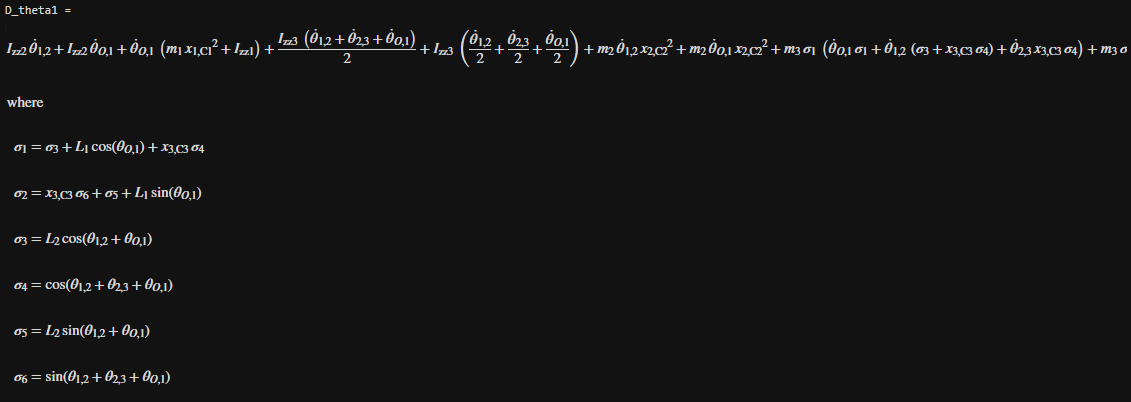
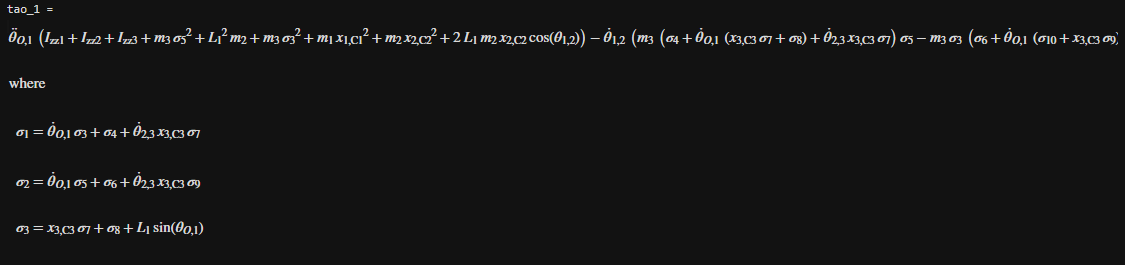
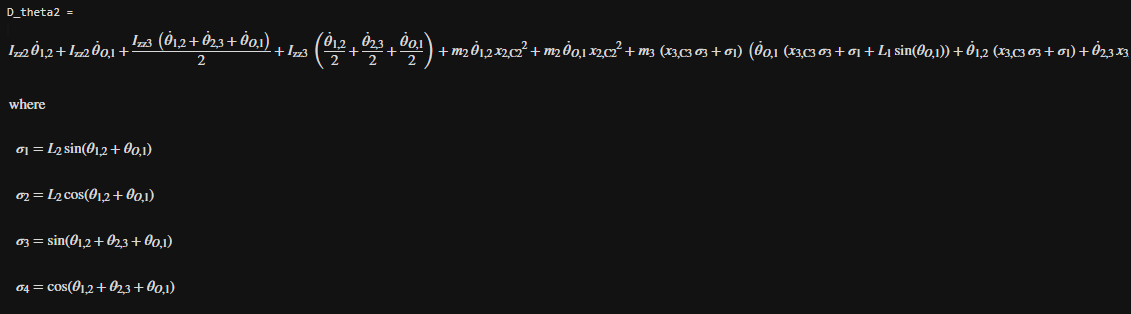
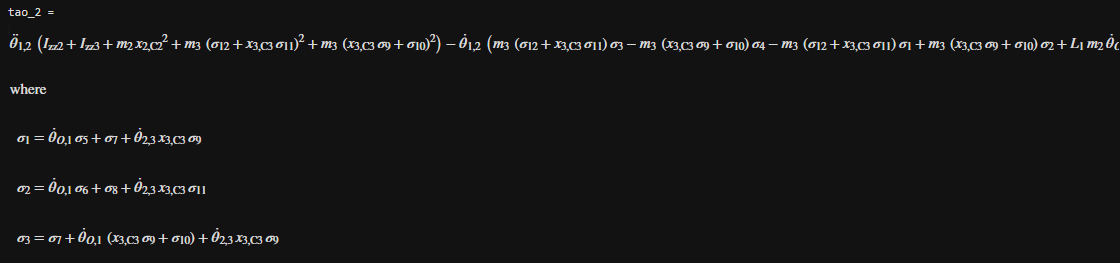
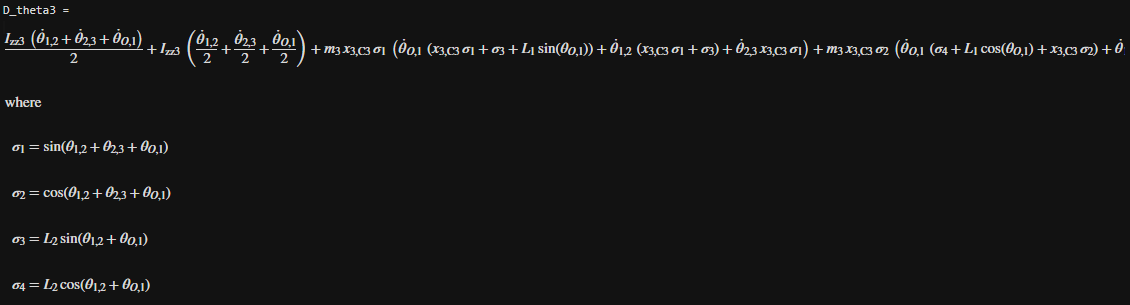
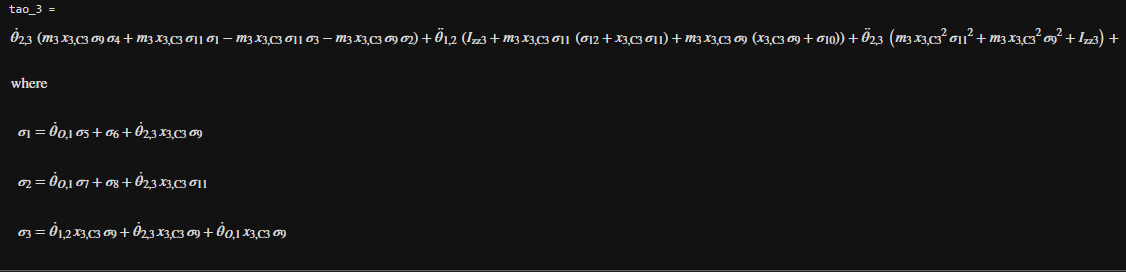
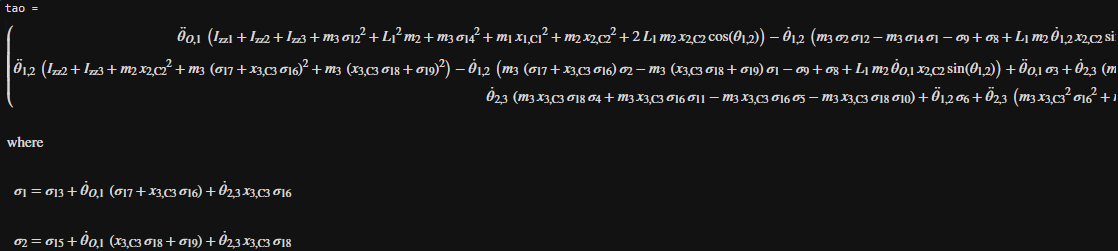
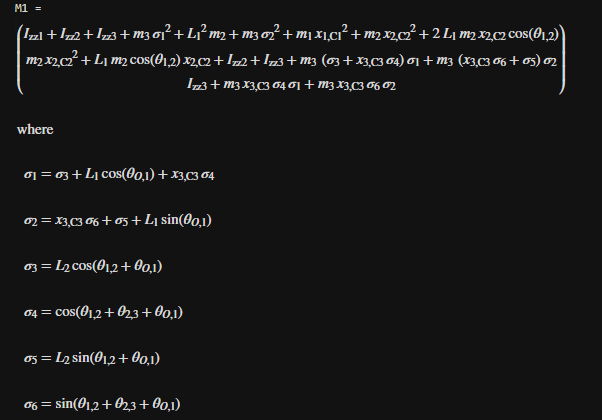
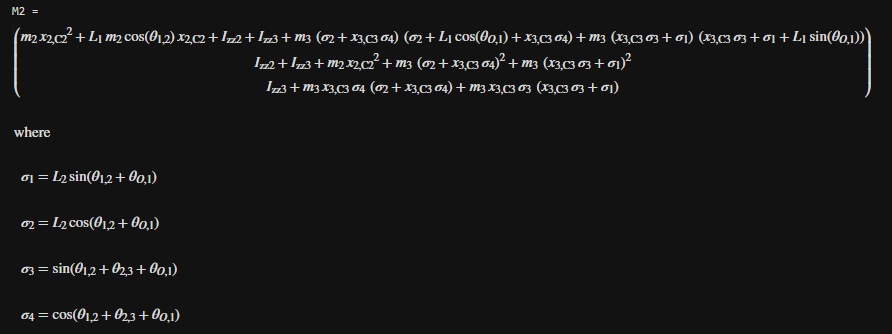
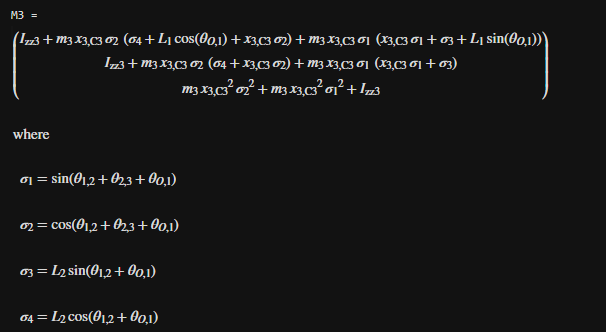
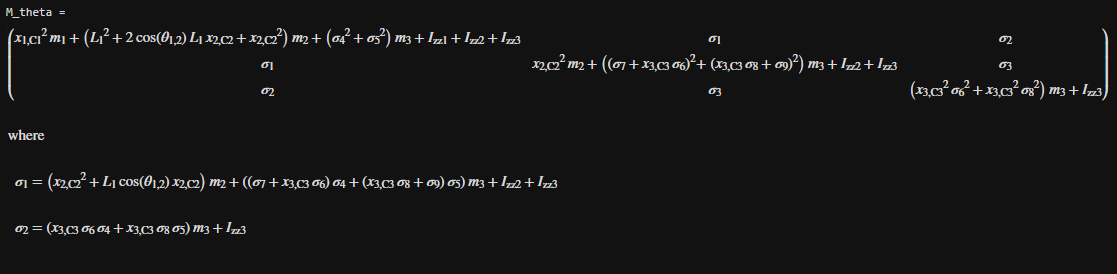

Vector par
